# Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import glob
import os

## CARREGAMENTO, LIMPEZA E TRATAMENTO DOS ARQUIVOS INDIVIDUALMENTE

In [2]:
# Realizar esse processo para cada dataset da pasta uploads
arquivo_csv = ('uploads/analise_txcg_2025.csv')
df = pd.read_csv(arquivo_csv, sep='#', encoding='utf-8-sig')
print(df.shape)

C:\Users\jcpsrodrigues\AppData\Local\Temp\ipykernel_11836\1049088866.py:3: DtypeWarning: Columns (5,12,14,15,17,18,20,21,22,23,24,25,43,44,49,50,54,59,60,61) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(arquivo_csv, sep='#', encoding='utf-8-sig')


(7874977, 64)


## VALIDAÇÃO RÁPIDA

In [3]:
pendentes = df['data_baixa'].isna().sum()
print(f"Pendentes: {pendentes}")

Pendentes: 1532336


In [4]:
baixados = df['data_baixa'].notna().sum()
print(f"Baixados: {baixados}")

Baixados: 6342641


In [5]:
tx_cong_global = (100 * pendentes/(pendentes+baixados)).round(2)
print(f"Taxa de Congestionamento Global: {tx_cong_global} %")

Taxa de Congestionamento Global: 19.46 %


In [ ]:
# Verificando se na coluna data_baixa e data_distribuicao tem o ANO e quantos são:
# Converte a coluna para o tipo datetime
ANO = 2026
df['data_baixa'] = pd.to_datetime(df['data_baixa'], errors='coerce') # errors='coerce' transforma erros em NaT (nulo)
df['data_distribuicao'] = pd.to_datetime(df['data_distribuicao'], errors='coerce') 

print("="*60)
print("--- VALIDAÇÃO DE DATA_BAIXA ---")
# Faz a verificação
temp = (df['data_baixa'].dt.year == ANO).any()
print(temp)

# Se quiser saber QUANTOS registros existem com o ano 2019:
qtd = (df['data_baixa'].dt.year == ANO).sum()
print(f"Total de registros de data_baixa em {ANO}: {qtd}")

print("="*60)
print("--- VALIDAÇÃO DE DATA_DISTRIBUICAO ---")
# Faz a verificação
temp2 = (df['data_distribuicao'].dt.year == ANO).any()
print(temp2)

# Se quiser saber QUANTOS registros existem com o ano 2019:
qtd2 = (df['data_distribuicao'].dt.year == ANO).sum()
print(f"Total de registros de data_distribuicao em {ANO}: {qtd2}")

## LIMPEZA E TRATAMENTO DAS DATAS DO ARQUIVO_CSV

In [15]:
# Limpeza e tratamento das datas do arquivo_csv
# 1. Converter as colunas de data para datetime
df['data_distribuicao'] = pd.to_datetime(df['data_distribuicao'], errors='coerce')
df['data_baixa'] = pd.to_datetime(df['data_baixa'], errors='coerce')

# 2. Verificar quantas datas inválidas temos
print(f"\nDatas inválidas na conversão:")
print(f"- data_distribuicao: {df['data_distribuicao'].isna().sum()} valores NaT")
print(f"- data_baixa: {df['data_baixa'].isna().sum()} valores NaT")

# 3. Extrair o ano de cada data
df['ano_distribuicao'] = df['data_distribuicao'].dt.year
df['ano_baixa'] = df['data_baixa'].dt.year

# 4. Fazer a limpeza: manter apenas registros em que:
#    - ano_distribuicao <= ANO (ou é NaN)
#    - ano_baixa <= ANO (ou é NaN)
ANO = 2025
df_limpo = df[
    (
        (df['ano_distribuicao'] <= ANO)
    ) & 
    (
        (df['ano_baixa'] >= 2020) & (df['ano_baixa'] <= ANO) | 
        (df['ano_baixa'].isna())
    )
].copy()

print(f"\nShape após limpeza: {df_limpo.shape}")
print(f"Registros removidos: {len(df) - len(df_limpo)}")

# 5. Verificação detalhada
print(f"\nVerificação dos anos nas datas:")
print(f"Anos únicos em data_distribuicao: {sorted(df_limpo['ano_distribuicao'].dropna().unique().astype(int))}")
print(f"Anos únicos em data_baixa: {sorted(df_limpo['ano_baixa'].dropna().unique().astype(int))}")

# 6. Mostrar exemplos de registros removidos (se houver)
if len(df) > len(df_limpo):
    df_removidos = df[~df.index.isin(df_limpo.index)]
    print(f"\nExemplo de registros removidos:")
    print(df_removidos[['data_distribuicao', 'data_baixa', 'ano_distribuicao', 'ano_baixa']].sample(5))
    
    # Contar motivo da remoção
    print(f"\nMotivo da remoção:")
    # Distribuição > ANO
    ANO = 2025
    dist_maior_ANO = df[df['ano_distribuicao'] > ANO]
    dist_nula = df[df['ano_distribuicao'].isna()]
    baixa_maior_ANO = df[df['ano_baixa'] > ANO]
    baixa_menor_2020 = df[df['ano_baixa'] < 2020]
    
    print(f"- data_distribuicao > {ANO}: {len(dist_maior_ANO)} registros")
    print(f"- data_distribuicao NULA: {len(dist_nula)} registros")
    print(f"- data_baixa > {ANO}: {len(baixa_maior_ANO)} registros")
    print(f"- data_baixa < 2020: {len(baixa_menor_2020)} registros")
    
    # Intersecção (ambos > ANO)
    ambos_maior_ANO = df[(df['ano_distribuicao'] > ANO) & (df['ano_baixa'] > ANO)]
    print(f"- ambos > {ANO}: {len(ambos_maior_ANO)} registros")

# 7. Opcional: Remover as colunas auxiliares de ano se não precisar mais
# df_limpo = df_limpo.drop(columns=['ano_distribuicao', 'ano_baixa'])

# 8. Mostrar estatísticas do dataframe limpo
print(f"\n{'='*50}")
print("RESUMO DO DATAFRAME LIMPO:")
print(f"{'='*50}")
print(f"Total de registros: {len(df_limpo)}")
print(f"Total de colunas: {len(df_limpo.columns)}")
print(f"\nTipos de dados:")
print(df_limpo.dtypes)

# 9. Verificar valores nulos nas datas
print(f"\nValores nulos nas datas (após limpeza):")
print(f"- data_distribuicao: {df_limpo['data_distribuicao'].isna().sum()} nulos ({df_limpo['data_distribuicao'].isna().sum()/len(df_limpo)*100:.1f}%)")
print(f"- data_baixa: {df_limpo['data_baixa'].isna().sum()} nulos ({df_limpo['data_baixa'].isna().sum()/len(df_limpo)*100:.1f}%)")


Datas inválidas na conversão:
- data_distribuicao: 3 valores NaT
- data_baixa: 1532336 valores NaT

Shape após limpeza: (7872856, 66)
Registros removidos: 2121

Verificação dos anos nas datas:
Anos únicos em data_distribuicao: [np.int64(1858), np.int64(1879), np.int64(1903), np.int64(1911), np.int64(1919), np.int64(1920), np.int64(1922), np.int64(1925), np.int64(1926), np.int64(1927), np.int64(1928), np.int64(1931), np.int64(1932), np.int64(1933), np.int64(1936), np.int64(1938), np.int64(1939), np.int64(1940), np.int64(1941), np.int64(1942), np.int64(1943), np.int64(1944), np.int64(1946), np.int64(1947), np.int64(1948), np.int64(1950), np.int64(1952), np.int64(1953), np.int64(1954), np.int64(1955), np.int64(1956), np.int64(1957), np.int64(1958), np.int64(1959), np.int64(1960), np.int64(1961), np.int64(1962), np.int64(1963), np.int64(1964), np.int64(1965), np.int64(1966), np.int64(1967), np.int64(1968), np.int64(1969), np.int64(1970), np.int64(1971), np.int64(1972), np.int64(1973), np.

In [18]:
# Validação da Limpeza do dataframe
ANO = 2026
df_limpo.info()
df_limpo_distribuicao = df_limpo[(df_limpo['ano_distribuicao'] == ANO)].head(10)
df_limpo_baixa = df_limpo[(df_limpo['ano_baixa'] == ANO)].head(10)

print('###################### data_distribuicao com ano = ANO ######################')
print(df_limpo_distribuicao)
print('######################### data_baixa com ano = ANO ##########################')
print(df_limpo_baixa)

<class 'pandas.core.frame.DataFrame'>
Index: 7872856 entries, 0 to 7874976
Data columns (total 66 columns):
 #   Column                           Dtype         
---  ------                           -----         
 0   processo_id                      int64         
 1   comarca                          object        
 2   comarca_id                       int64         
 3   entrancia                        object        
 4   serventia                        object        
 5   codg_serventia_cnj               object        
 6   vara_oficial_id                  int64         
 7   origem                           object        
 8   is_conhecimento                  object        
 9   grupo_cnj_id                     int64         
 10  is_recurso                       object        
 11  processo                         object        
 12  natureza                         object        
 13  codg_natureza                    float64       
 14  fase                             object

## Ordenar e Remover Duplicatas

In [20]:
df = df_limpo.copy()
# Ordenar para garantir que os registros mais recentes (com baixa preenchida) fiquem por último

# Isso garante que se um processo era nulo no df1 e foi baixado no df2, a versão baixada prevaleça.
df = df.sort_values(by=['processo_id', 'data_baixa'], na_position='first')

# Remover duplicatas, mantendo a última ocorrência (a mais atualizada)
df = df.drop_duplicates(subset=['processo_id'], keep='last').copy()

print(df.shape)

(7872856, 66)


## Limpeza e Tratamento

In [24]:
# Verificar o nome correto das colunas (pode haver diferenças de acentuação ou espaços)
colunas = df.columns.tolist()

# Encontrar as colunas de data corretamente
coluna_serventia = [col for col in colunas if 'serventia' in col.lower()][0]
coluna_distribuicao = [col for col in colunas if 'data_distribuicao' in col.lower()][0]
coluna_baixa = [col for col in colunas if 'data_baixa' in col.lower()][0]
coluna_area_acao = [col for col in colunas if 'nome_area_acao' in col.lower()][0]
coluna_processo_id = [col for col in colunas if 'processo_id' in col.lower()][0]
coluna_comarca = [col for col in colunas if 'comarca' in col.lower()][0]

# Renomear colunas para garantir consistência
df = df.rename(columns={
coluna_distribuicao: 'data_distribuicao',
coluna_baixa: 'data_baixa',
coluna_area_acao: 'nome_area_acao',
coluna_processo_id: 'processo_id',
coluna_comarca: 'comarca',
coluna_serventia: 'serventia'
})

# ==========================================================================================================================================
# ANÁLISE MENSAL
# ==========================================================================================================================================

In [ ]:
# 0) Garantir datetime
df['data_distribuicao'] = pd.to_datetime(df['data_distribuicao'], errors='coerce')
df['data_baixa'] = pd.to_datetime(df['data_baixa'], errors='coerce')

keys = ['comarca', 'serventia']

# 1) Cópia para manipulação
df_f = df.copy()

# 2) Criar referências de período (Mês/Ano)
df_f['mes_dist'] = df_f['data_distribuicao'].dt.to_period('M')
df_f['mes_baixa'] = df_f['data_baixa'].dt.to_period('M')

# 3) Fluxos Mensais (Base para o incremento)
dist_mes = (
    df_f.groupby(keys + ['mes_dist'])
    .size()
    .rename('Distribuidos_mes')
    .reset_index()
    .rename(columns={'mes_dist': 'mes_ref'})
)

baix_mes = (
    df_f.dropna(subset=['data_baixa'])
    .groupby(keys + ['mes_baixa'])
    .size()
    .rename('Baixados_mes')
    .reset_index()
    .rename(columns={'mes_baixa': 'mes_ref'})
)

# 4) Merge dos fluxos para criar a linha do tempo completa
df_global_mensal = pd.merge(
    dist_mes, 
    baix_mes, 
    on=keys + ['mes_ref'], 
    how='outer'
).fillna(0)

# 5) O CORAÇÃO DA LÓGICA: Incremento Acumulado
# Ordenar para garantir que o deslocamento temporal e o rolling window sejam corretos
df_global_mensal = df_global_mensal.sort_values(keys + ['mes_ref'])

# Acumulamos TUDO desde o início da base para definir o Estoque Real (Pendentes)
df_global_mensal['Distribuídos_Acum_Global'] = (
    df_global_mensal.groupby(keys)['Distribuidos_mes'].cumsum()
)

df_global_mensal['Baixados_Acum_Global'] = (
    df_global_mensal.groupby(keys)['Baixados_mes'].cumsum()
)

# 6) Cálculo dos Pendentes (Estoque Real no fim de cada mês)
# Pendentes_mes = (Total que entrou na história) - (Total que saiu na história)
df_global_mensal['Pendentes_mes'] = (
    df_global_mensal['Distribuídos_Acum_Global'] - df_global_mensal['Baixados_Acum_Global']
).astype(int)

# 7) A SOLUÇÃO: Baixados nos Últimos 12 Meses (Rolling Window)
# Isso impede o "reset" de Janeiro e mantém a taxa realista, herdando a produtividade do ano anterior
df_global_mensal['Baixados_12_Meses'] = (
    df_global_mensal.groupby(keys)['Baixados_mes']
    .transform(lambda x: x.rolling(window=12, min_periods=1).sum())
)

# 8) Taxa de Congestionamento (Padrão CNJ com Janela Deslizante)
# Denominador = Pendentes Atuais + Soma das Baixas dos últimos 12 meses (Capacidade de Vazão)
df_global_mensal['Taxa_Cong_Global (%)'] = np.where(
    (df_global_mensal['Pendentes_mes'] + df_global_mensal['Baixados_12_Meses']) > 0,
    (df_global_mensal['Pendentes_mes'] / (df_global_mensal['Pendentes_mes'] + df_global_mensal['Baixados_12_Meses'])) * 100,
    0
).round(2)

# 9) Organização Final
# Convertendo fluxos para int (pós-fillna)
df_global_mensal['Distribuidos_mes'] = df_global_mensal['Distribuidos_mes'].astype(int)
df_global_mensal['Baixados_mes'] = df_global_mensal['Baixados_mes'].astype(int)

# Seleção das colunas finais conforme o padrão solicitado
colunas_finais = keys + [
    'mes_ref', 
    'Distribuidos_mes', 
    'Baixados_mes', 
    'Pendentes_mes', 
    'Taxa_Cong_Global (%)'
]

df_global_mensal = df_global_mensal[colunas_finais].sort_values(keys + ['mes_ref'])

# Opcional: Visualizar resultado para conferência técnica
# print(df_global_mensal.tail(12))

In [53]:
# Filtrando todos os MESES de cada ano para exração MENSAL
ano_alvo = 2025
df_mes = df_global_mensal[df_global_mensal['mes_ref'].dt.year == ano_alvo]
df_mes.head(13)

,comarca,serventia,mes_ref,Distribuidos_mes,Baixados_mes,Pendentes_mes,Taxa_Cong_Global (%)
272,ABADIÂNIA,Vara Judicial,2025-01,142,89,3166,59.49
273,ABADIÂNIA,Vara Judicial,2025-02,148,231,3083,58.39
274,ABADIÂNIA,Vara Judicial,2025-03,129,207,3005,56.73
275,ABADIÂNIA,Vara Judicial,2025-04,170,155,3020,57.84
276,ABADIÂNIA,Vara Judicial,2025-05,188,256,2952,57.26
277,ABADIÂNIA,Vara Judicial,2025-06,169,229,2892,55.99
278,ABADIÂNIA,Vara Judicial,2025-07,133,331,2694,53.39
279,ABADIÂNIA,Vara Judicial,2025-08,174,151,2717,54.34
280,ABADIÂNIA,Vara Judicial,2025-09,160,207,2670,53.50
281,ABADIÂNIA,Vara Judicial,2025-10,224,166,2728,54.31


In [54]:
filtro = (
    (df_global_mensal['comarca'] == 'APARECIDA DE GOIÂNIA') & 
    (df_global_mensal['serventia'] == '1ª Vara Cível') &
    (df_global_mensal['mes_ref'].astype(str).str.contains('2023'))
)
df_global_mensal[filtro].head(12)

,comarca,serventia,mes_ref,Distribuidos_mes,Baixados_mes,Pendentes_mes,Taxa_Cong_Global (%)
9978,APARECIDA DE GOIÂNIA,1ª Vara Cível,2023-01,127,42,5314,84.26
9979,APARECIDA DE GOIÂNIA,1ª Vara Cível,2023-02,125,49,5390,84.48
9980,APARECIDA DE GOIÂNIA,1ª Vara Cível,2023-03,136,67,5459,85.40
9981,APARECIDA DE GOIÂNIA,1ª Vara Cível,2023-04,128,82,5505,85.83
9982,APARECIDA DE GOIÂNIA,1ª Vara Cível,2023-05,149,110,5544,85.65
9983,APARECIDA DE GOIÂNIA,1ª Vara Cível,2023-06,143,59,5628,86.40
9984,APARECIDA DE GOIÂNIA,1ª Vara Cível,2023-07,150,86,5692,87.22
9985,APARECIDA DE GOIÂNIA,1ª Vara Cível,2023-08,175,138,5729,86.95
9986,APARECIDA DE GOIÂNIA,1ª Vara Cível,2023-09,139,146,5722,86.54
9987,APARECIDA DE GOIÂNIA,1ª Vara Cível,2023-10,131,90,5763,86.31


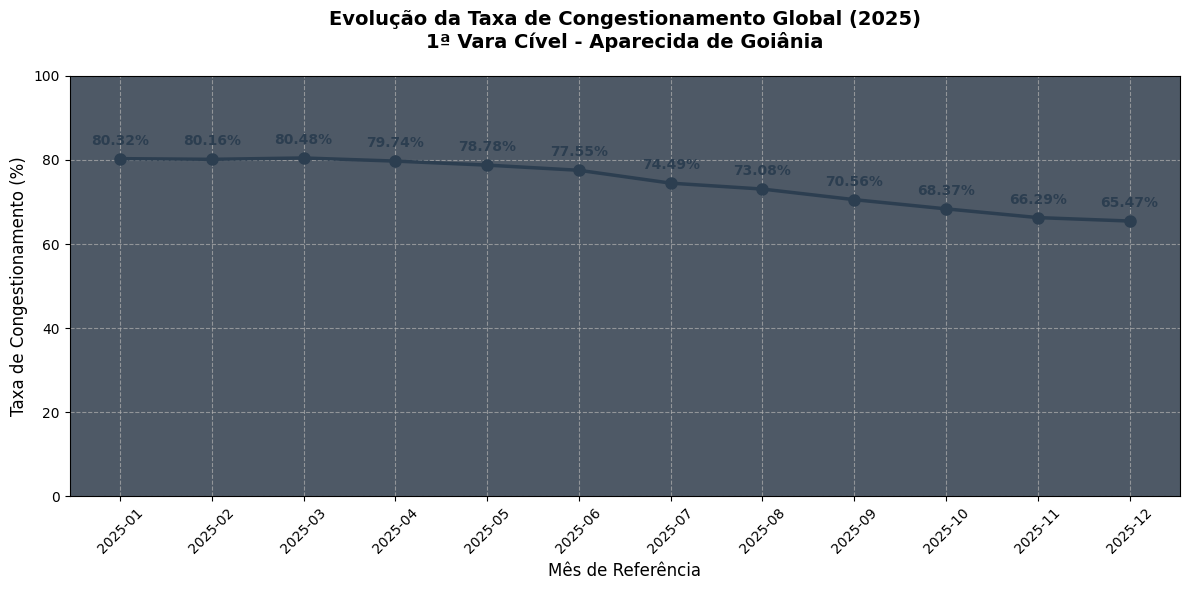

In [55]:
import matplotlib.pyplot as plt

# 1) Aplicar o seu filtro
filtro = (
    (df_global_mensal['comarca'] == 'APARECIDA DE GOIÂNIA') & 
    (df_global_mensal['serventia'] == '1ª Vara Cível') &
    (df_global_mensal['mes_ref'].astype(str).str.contains('2025'))
)

df_plot = df_global_mensal[filtro].copy()

# 2) Preparação dos dados
# Converter mes_ref para string para evitar problemas de formatação de datas no eixo X
x = df_plot['mes_ref'].astype(str).tolist()
y = df_plot['Taxa_Cong_Global (%)'].tolist()

# 3) Criação do Gráfico (Pure Matplotlib)
fig, ax = plt.subplots(figsize=(12, 6))

# Plotagem da linha e dos pontos
ax.plot(x, y, marker='o', linestyle='-', linewidth=2.5, color='#2c3e50', markersize=8, label='Taxa Global')

# 4) Estilização Técnica
ax.set_title('Evolução da Taxa de Congestionamento Global (2025)\n1ª Vara Cível - Aparecida de Goiânia', 
             fontsize=14, pad=20, fontweight='bold')
ax.set_xlabel('Mês de Referência', fontsize=12)
ax.set_ylabel('Taxa de Congestionamento (%)', fontsize=12)

# Grid personalizada (estilo whitegrid manual)
ax.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True) # Garante que o grid fique atrás da linha

# Limites do eixo Y (Taxa de 0 a 100)
ax.set_ylim(0, 100)

# 5) Adição de Data Labels (Valores sobre os pontos)
for i, valor in enumerate(y):
    ax.annotate(f'{valor}%', 
                (x[i], y[i]), 
                textcoords="offset points", 
                xytext=(0, 10), 
                ha='center', 
                fontsize=10, 
                fontweight='bold',
                color='#2c3e50')

# Rotação dos meses para melhor leitura
plt.xticks(rotation=45)

# Ajuste fino para não cortar os rótulos
plt.tight_layout()

# Exibir
plt.show()

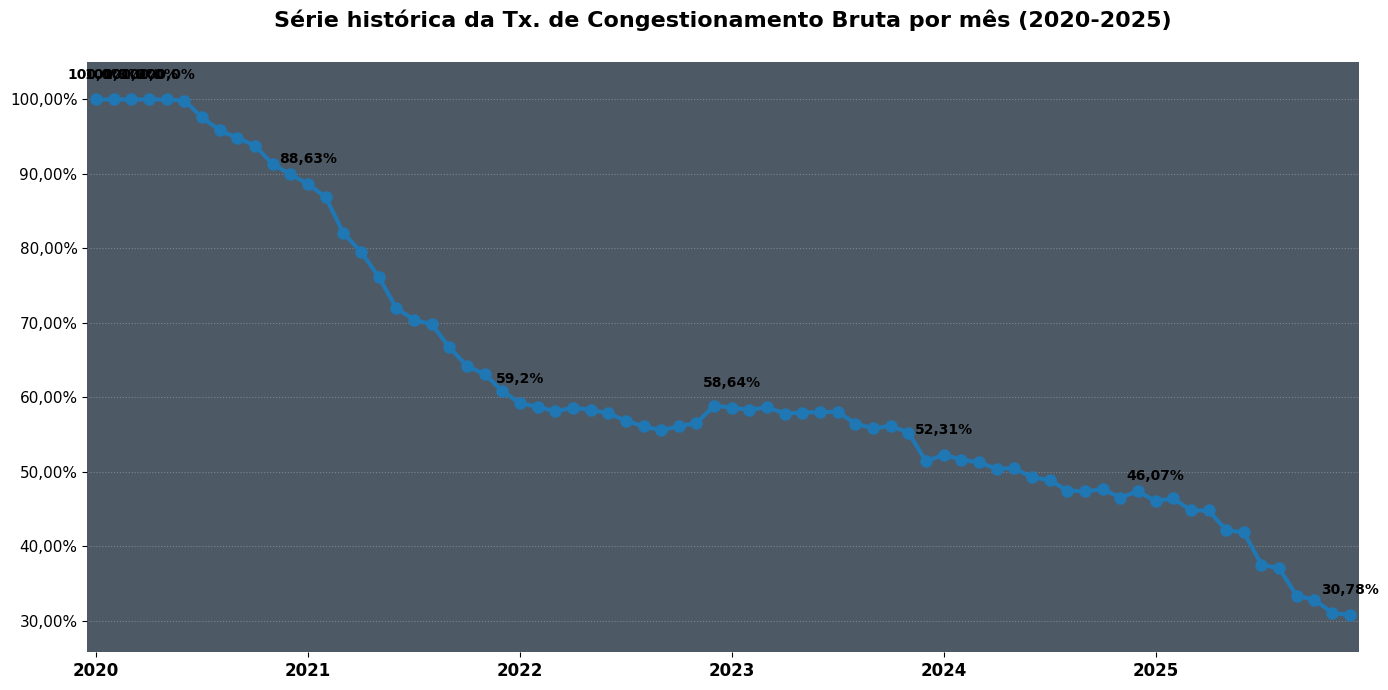

In [56]:
import matplotlib.pyplot as plt

# 1) Filtrar estritamente entre 2020 e 2025
filtro = (
    (df_global_mensal['comarca'] == 'GOIÂNIA') & 
    (df_global_mensal['serventia'] == '2ª Vara Criminal dos Crimes Dolosos contra a Vida e Tribunal do Júri') &
    (df_global_mensal['mes_ref'].dt.year >= 2020) &
    (df_global_mensal['mes_ref'].dt.year <= 2025)
)

df_plot = df_global_mensal[filtro].copy()

# 2) Preparação dos dados
df_plot = df_plot.sort_values('mes_ref')
x = df_plot['mes_ref'].astype(str).tolist()
y = df_plot['Taxa_Cong_Global (%)'].tolist()

# 3) Configuração Visual (Matplotlib puro)
fig, ax = plt.subplots(figsize=(14, 7))

# Cor e Estilo da Linha (Verde limão da imagem)
ax.plot(x, y, marker='o', linestyle='-', linewidth=3, 
        markersize=8)

# 4) Estilização de Títulos e Eixos
ax.set_title('Série histórica da Tx. de Congestionamento Bruta por mês (2020-2025)', 
             fontsize=16, pad=25, fontweight='bold')

ax.tick_params(axis='both', labelsize=11)

# Ajuste automático do limite Y baseado nos dados para manter o "zoom" da imagem
min_y = min(y) - 5
max_y = max(y) + 5
ax.set_ylim(min_y, max_y)

# Formatação do Eixo Y para porcentagem
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x)},00%'))

# Remover bordas
for spine in ax.spines.values():
    spine.set_visible(False)

# Grid horizontal pontilhada
ax.yaxis.grid(True, linestyle=':', alpha=0.5)

# 5) Data Labels Estratégicos (Início do ano, Pico, Vale e Atual)
for i, valor in enumerate(y):
    # Rótulo se for Janeiro, o último mês, o maior ou o menor valor
    if "-01" in x[i] or i == len(y)-1 or valor == max(y) or valor == min(y):
        ax.annotate(f'{str(valor).replace(".", ",")}%', 
                    (x[i], y[i]), 
                    textcoords="offset points", 
                    xytext=(0, 15), 
                    ha='center', 
                    fontsize=10, 
                    fontweight='bold')

# 6) Ajuste Fino do Eixo X (Apenas os Anos)
ticks_pos = []
ticks_labels = []
for i, mes in enumerate(x):
    if "-01" in mes: # Identifica Janeiro para marcar o ano
        ticks_pos.append(i)
        ticks_labels.append(mes.split("-")[0])

ax.set_xticks(ticks_pos)
ax.set_xticklabels(ticks_labels, fontweight='bold', fontsize=12)

# Garante que o gráfico não tenha espaços vazios nas pontas
ax.set_xlim(-0.5, len(x)-0.5)

plt.tight_layout()
plt.show()

## GRAVA ARQUIVO MENSAL CONCATENADO, NO FORMATO JSON, NA PASTA RESULTS_CONCAT

In [ ]:
# Grava o arquivo MENSAL concatenado, no formato JSON, na pasta results_concat
os.makedirs("results_concat", exist_ok=True)
df_global_mensal.to_json("results_concat/tx_cong_mensal.json", orient="records", force_ascii=False)